# LIBRARY IMPORT

In [38]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import kendalltau, pearsonr, spearmanr
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils import resample
from sklearn.tree import plot_tree
from sklearn.preprocessing import label_binarize, LabelEncoder

# IMPORTING DATASET AND PRE-PROCESSING

In [39]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

file_link = 'https://drive.google.com/file/d/1J9d9FO75689JxXTMl7eGB-MLAACA7bpU/view?usp=sharing'
id = file_link.split("/")[-2]
new_link = f'https://drive.google.com/uc?id={id}'
df = pd.read_csv(new_link)

df = df.drop(['user_id'], axis=1)
df = df.drop(['churn_probability'], axis=1)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 47 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          250 non-null    int64  
 1   gender                       250 non-null    object 
 2   country                      250 non-null    object 
 3   occupation                   250 non-null    object 
 4   income_level                 250 non-null    object 
 5   years_gaming                 250 non-null    int64  
 6   preferred_genre              250 non-null    object 
 7   platform                     250 non-null    object 
 8   device_type                  250 non-null    object 
 9   rank_tier                    250 non-null    object 
 10  daily_playtime_hours         250 non-null    float64
 11  weekly_play_sessions         250 non-null    int64  
 12  late_night_sessions_hours    250 non-null    float64
 13  weekend_playtime_hou

# HEATMAP

Features: 47
Data Points: 250
Quantitative: ['age', 'years_gaming', 'daily_playtime_hours', 'weekly_play_sessions', 'late_night_sessions_hours', 'weekend_playtime_hours', 'consecutive_hours_max', 'multiplayer_ratio', 'toxic_chat_reports', 'rage_quit_frequency', 'in_game_purchases', 'monthly_spending_usd', 'lootbox_openings', 'stress_score', 'loneliness_score', 'dopamine_dependency_index', 'self_control_score', 'impulsiveness_score', 'anxiety_level', 'depression_indicator', 'emotional_stability', 'sleep_hours', 'exercise_frequency_per_week', 'caffeine_intake_cups_day', 'social_interaction_hours', 'gpa_or_performance_score', 'missed_deadlines', 'productivity_drop_percent', 'absenteeism_days', 'internet_speed_mbps', 'screen_time_total_hours', 'addiction_score', 'addiction_binary', 'burnout_probability', 'mental_health_risk_score']
Categorical: ['gender', 'country', 'occupation', 'income_level', 'preferred_genre', 'platform', 'device_type', 'rank_tier', 'subscription_status', 'relationship

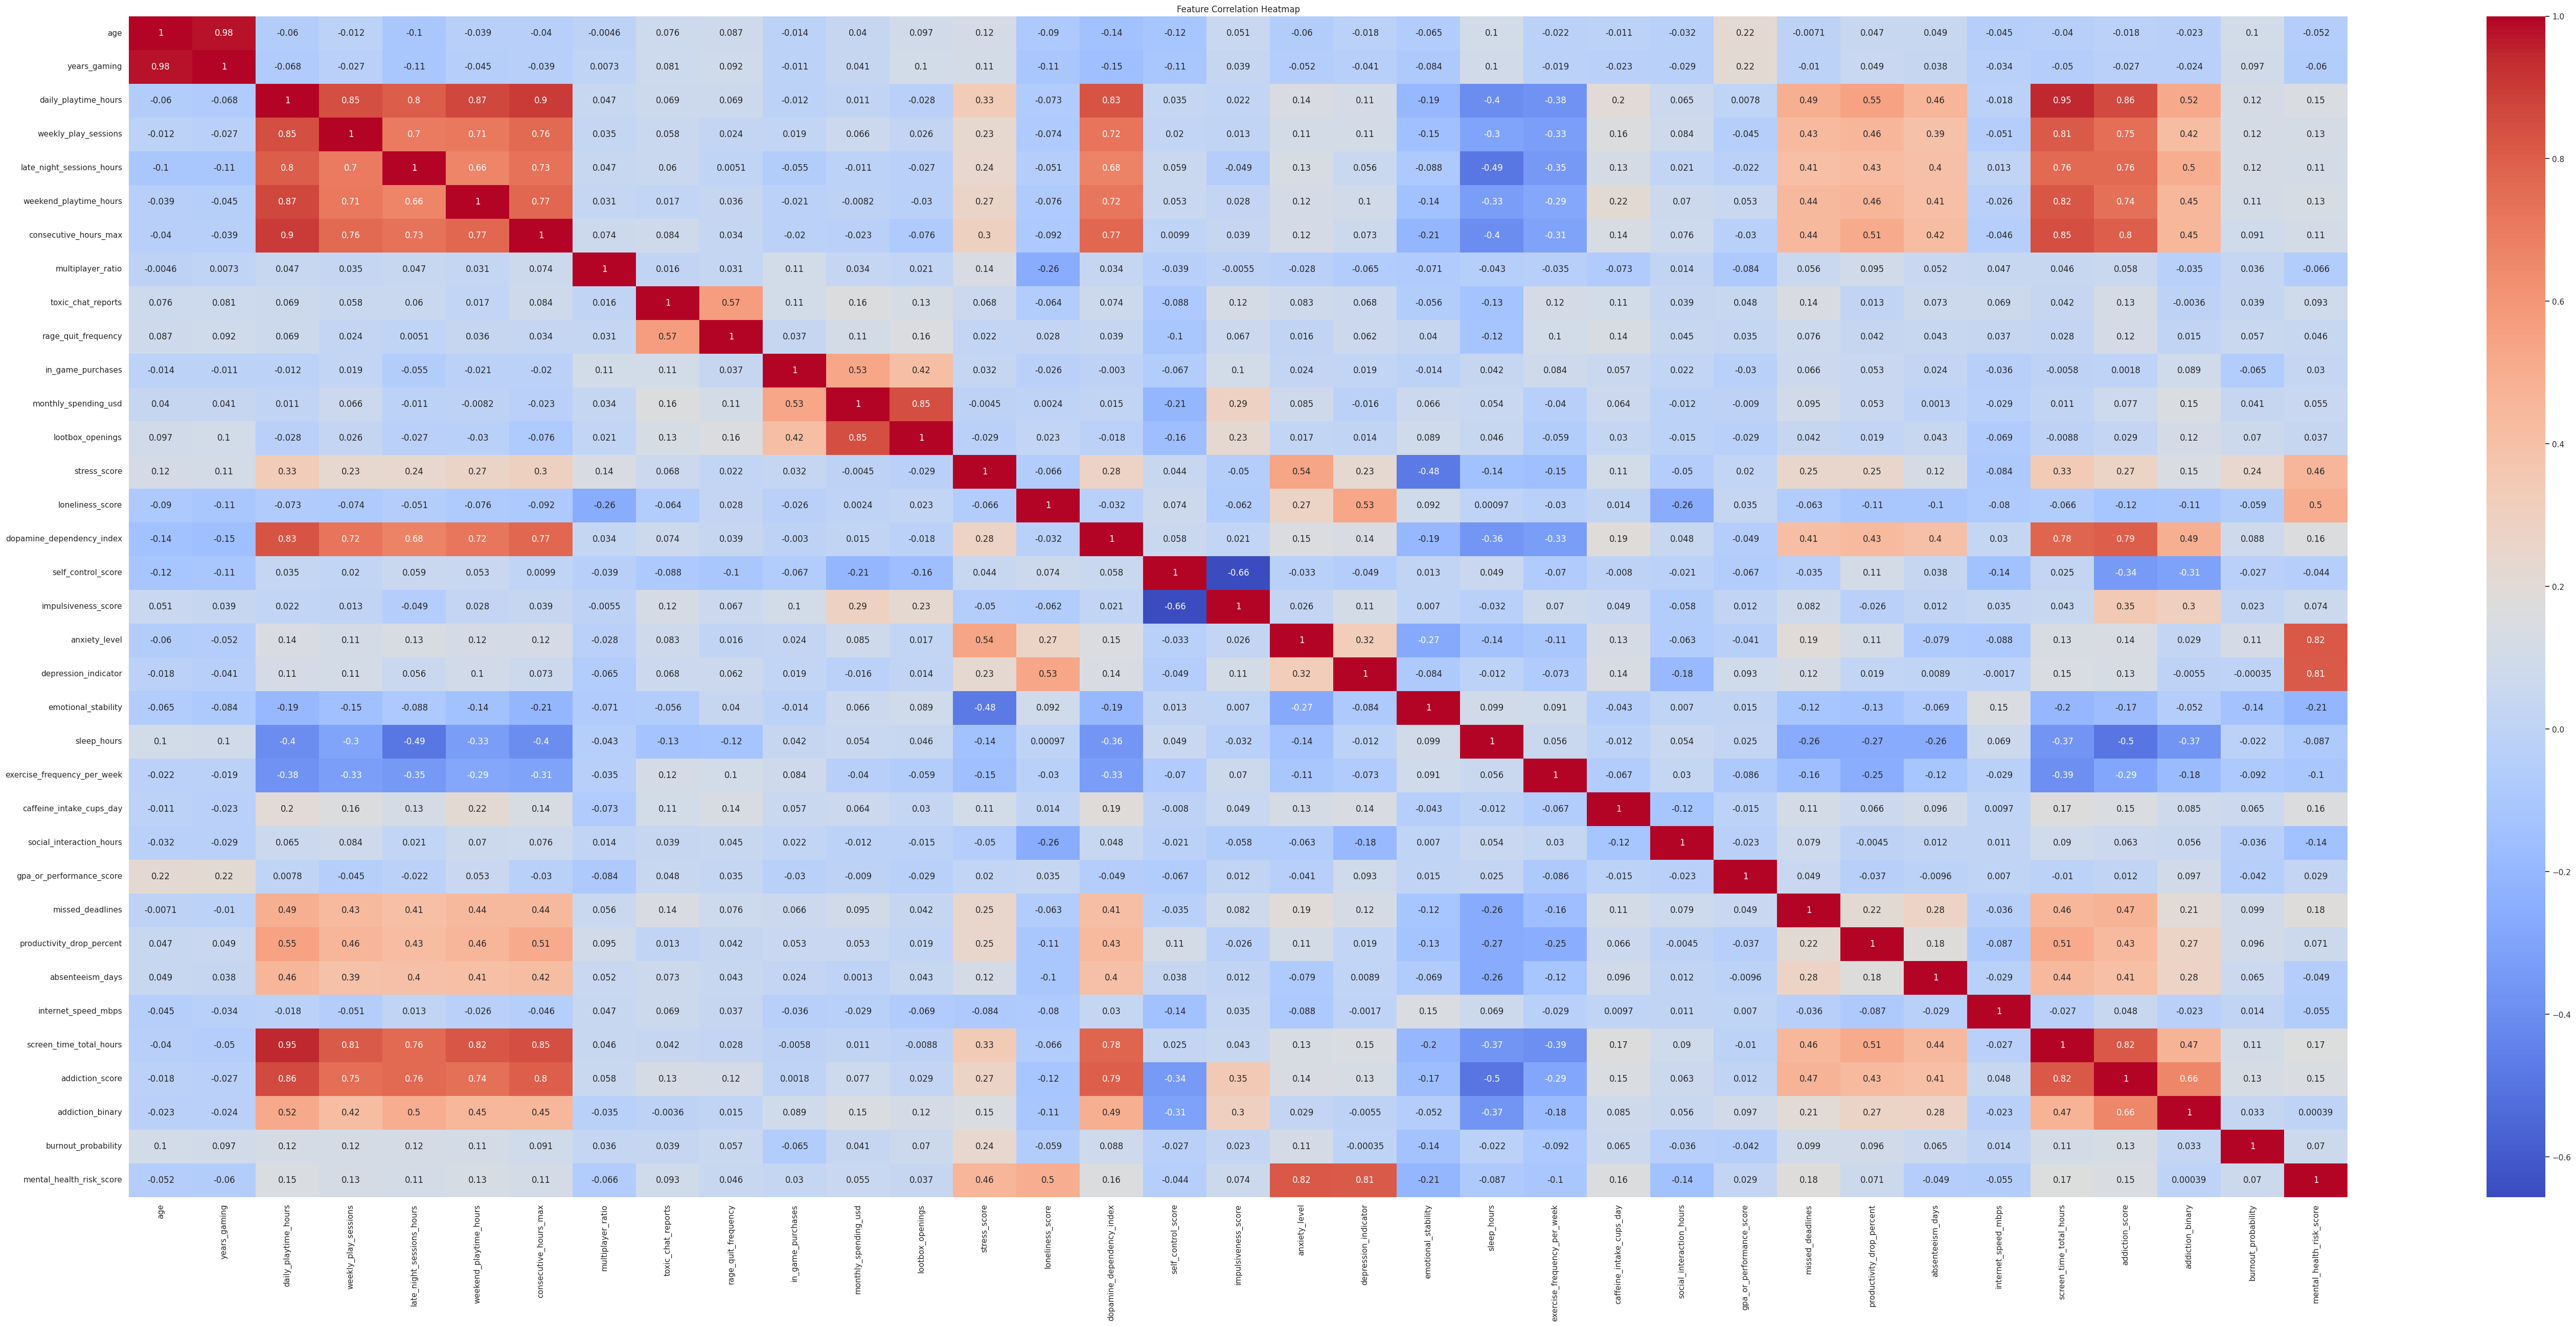

In [40]:
print(f"Features: {df.shape[1]}")
print(f"Data Points: {df.shape[0]}")

print("Quantitative:", df.select_dtypes(include=['number']).columns.tolist())
print("Categorical:", df.select_dtypes(include=['object']).columns.tolist())

df_encoded = df.copy()
le = LabelEncoder()
df_numerical = df.select_dtypes(include=['number'])
for col in df.select_dtypes(include=['object']).columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

plt.figure(figsize=(70, 30))
sns.heatmap(df_numerical.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [41]:
df = df.drop(['daily_playtime_hours'], axis=1)
df = df.drop(['stress_score'], axis=1)
df = df.drop(['absenteeism_days'], axis=1)
df = df.drop(['internet_speed_mbps'], axis=1)
df = df.drop(['monthly_spending_usd'], axis=1)

# FIRST 15 ROWS OF PROCESSED DATASET

In [42]:
df.head(15)

,age,gender,country,occupation,income_level,years_gaming,preferred_genre,platform,device_type,rank_tier,...,gpa_or_performance_score,missed_deadlines,productivity_drop_percent,screen_time_total_hours,behavioral_cluster,addiction_score,addiction_binary,addiction_severity,burnout_probability,mental_health_risk_score
0,21,Male,India,Employed,Middle,9,Sandbox,PC,Laptop,Gold,...,4.00,4,0.0,5.4,Casual Enjoyer,27.61,0,Mild,1.00,0.920
1,25,Male,India,Employed,Lower-Middle,13,RPG,Mobile,Mixed,Bronze,...,4.00,4,16.7,13.4,Streamer/Creator,55.51,1,Moderate,1.00,0.515
2,26,Male,Brazil,Employed,Middle,14,RPG,PC+Mobile,High-end PC,Master,...,4.00,6,8.5,12.3,Streamer/Creator,45.85,0,Moderate,1.00,0.720
3,22,Male,South Korea,Employed,Upper-Middle,10,Strategy,PC+Mobile,Mobile,Bronze,...,4.00,3,8.7,6.9,Toxic Competitor,39.87,0,Mild,1.00,0.520
4,17,Female,India,Student,Middle,5,Strategy,PC,Laptop,Bronze,...,2.60,3,21.9,9.3,Competitive Grinder,46.97,0,Moderate,1.00,0.585
5,13,Male,USA,Freelancer,Middle,1,Horror,PC,Mobile,Silver,...,4.00,0,0.0,3.7,Casual Enjoyer,17.26,0,NaN,0.32,0.400
6,27,Male,UK,Unemployed,Lower-Middle,15,RPG,Console,Console,Silver,...,4.00,2,30.2,10.0,Toxic Competitor,34.82,0,Mild,1.00,0.550
7,18,Non-binary,Canada,Student,Middle,6,MOBA,PC,Mixed,Bronze,...,3.35,2,0.0,4.7,Casual Enjoyer,22.66,0,Mild,1.00,0.490
8,16,Female,USA,Student,High,1,Sports,Mobile,Mixed,Gold,...,2.72,3,35.2,11.0,Toxic Competitor,35.08,0,Mild,1.00,0.400
9,30,Female,Brazil,Freelancer,Middle,18,Strategy,Console,Mid-range PC,Gold,...,4.00,2,24.8,7.5,Competitive Grinder,46.24,0,Moderate,1.00,0.290


# IDENTIFICATION OF NUMERIC DATA

In [43]:
numerical_data = df.select_dtypes(include='number')

numerical_features=numerical_data.columns.tolist()

print(f'There are {len(numerical_features)} numerical features:', '\n')
print(numerical_features)

There are 30 numerical features: 

['age', 'years_gaming', 'weekly_play_sessions', 'late_night_sessions_hours', 'weekend_playtime_hours', 'consecutive_hours_max', 'multiplayer_ratio', 'toxic_chat_reports', 'rage_quit_frequency', 'in_game_purchases', 'lootbox_openings', 'loneliness_score', 'dopamine_dependency_index', 'self_control_score', 'impulsiveness_score', 'anxiety_level', 'depression_indicator', 'emotional_stability', 'sleep_hours', 'exercise_frequency_per_week', 'caffeine_intake_cups_day', 'social_interaction_hours', 'gpa_or_performance_score', 'missed_deadlines', 'productivity_drop_percent', 'screen_time_total_hours', 'addiction_score', 'addiction_binary', 'burnout_probability', 'mental_health_risk_score']


# IDENTIFICATION OF CLASSICAL DATA

In [44]:
categorical_data=df.select_dtypes(include= 'object')

categorical_features=categorical_data.columns.tolist()

print(f'There are {len(categorical_features)} categorical features:', '\n')
print(categorical_features)

There are 12 categorical features: 

['gender', 'country', 'occupation', 'income_level', 'preferred_genre', 'platform', 'device_type', 'rank_tier', 'subscription_status', 'relationship_status', 'behavioral_cluster', 'addiction_severity']


In [45]:
numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,250.0,22.160000,5.455037,13.00,18.00000,22.000,27.000,40.00
years_gaming,250.0,9.668000,5.460866,1.00,6.00000,9.000,14.750,25.00
weekly_play_sessions,250.0,7.056000,3.517721,1.00,4.00000,7.000,10.000,15.00
late_night_sessions_hours,250.0,2.102400,1.200700,0.00,1.12500,2.100,3.000,5.20
weekend_playtime_hours,250.0,8.368400,4.085876,0.50,5.60000,8.150,10.850,20.00
consecutive_hours_max,250.0,9.714800,4.828877,1.00,5.52500,10.100,13.175,20.60
multiplayer_ratio,250.0,0.462240,0.227391,0.00,0.30000,0.450,0.630,1.00
toxic_chat_reports,250.0,2.948000,5.451621,0.00,0.00000,1.000,2.000,32.00
rage_quit_frequency,250.0,1.896000,2.353581,0.00,0.00000,1.000,3.000,10.00
in_game_purchases,250.0,4.072000,4.565764,0.00,0.00000,3.000,7.000,21.00


In [46]:
categorical_data.describe().T

,count,unique,top,freq
gender,250,4,Male,158
country,250,15,USA,62
occupation,250,5,Employed,119
income_level,250,5,Middle,98
preferred_genre,250,10,MMORPG,39
platform,250,5,PC,103
device_type,250,6,Mixed,50
rank_tier,250,8,Gold,52
subscription_status,168,3,Premium,76
relationship_status,250,5,Single,110


In [47]:
numerical_data.var()

,0
age,29.757430
years_gaming,29.821060
weekly_play_sessions,12.374361
late_night_sessions_hours,1.441681
weekend_playtime_hours,16.694379
consecutive_hours_max,23.318053
multiplayer_ratio,0.051707
toxic_chat_reports,29.720177
rage_quit_frequency,5.539341
in_game_purchases,20.846201


In [48]:
numerical_data.skew()

,0
age,0.235941
years_gaming,0.231545
weekly_play_sessions,-0.037359
late_night_sessions_hours,0.102230
weekend_playtime_hours,0.370635
consecutive_hours_max,-0.034787
multiplayer_ratio,0.134029
toxic_chat_reports,3.033094
rage_quit_frequency,1.377698
in_game_purchases,1.255670


# Check Unique Values

In [49]:
df.nunique()

,0
age,25
gender,4
country,15
occupation,5
income_level,5
years_gaming,23
preferred_genre,10
platform,5
device_type,6
rank_tier,8


# Check for missing values

In [50]:
df.isnull().sum()

,0
age,0
gender,0
country,0
occupation,0
income_level,0
years_gaming,0
preferred_genre,0
platform,0
device_type,0
rank_tier,0


# FILLING OF NULL VALUES WITH MEDIAN

In [51]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())


for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())

age                            0
gender                         0
country                        0
occupation                     0
income_level                   0
years_gaming                   0
preferred_genre                0
platform                       0
device_type                    0
rank_tier                      0
weekly_play_sessions           0
late_night_sessions_hours      0
weekend_playtime_hours         0
consecutive_hours_max          0
multiplayer_ratio              0
toxic_chat_reports             0
rage_quit_frequency            0
in_game_purchases              0
lootbox_openings               0
subscription_status            0
loneliness_score               0
dopamine_dependency_index      0
self_control_score             0
impulsiveness_score            0
anxiety_level                  0
depression_indicator           0
emotional_stability            0
sleep_hours                    0
exercise_frequency_per_week    0
caffeine_intake_cups_day       0
social_int

# CHECKING IF OVERFITIING EXISTS

Class distribution:
gpa_group
High      189
Medium     56
Low         5
Name: count, dtype: int64


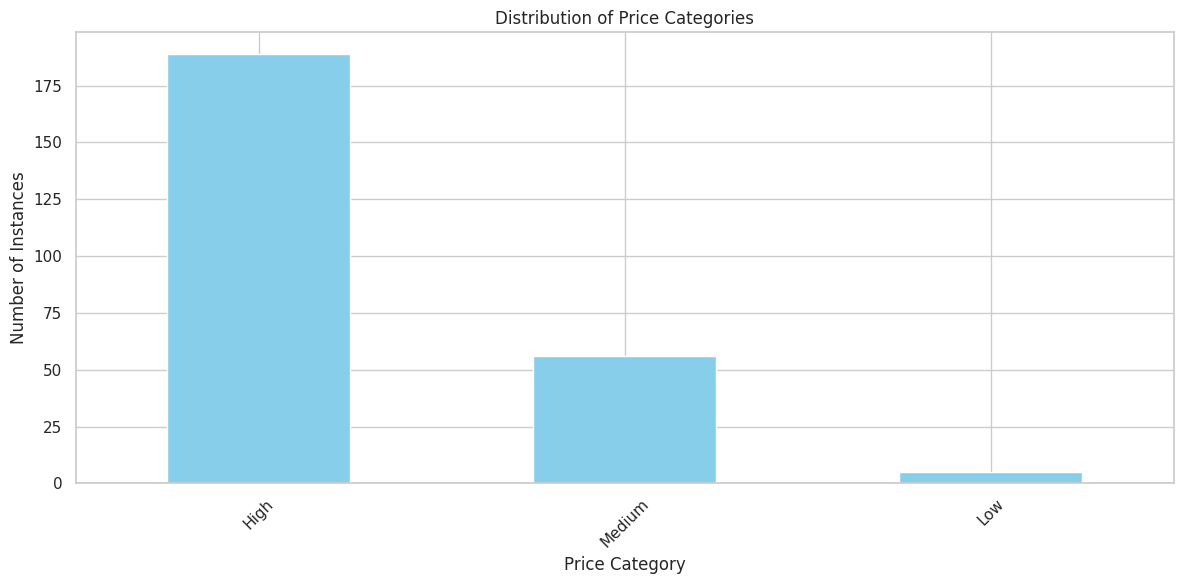

In [52]:
bins = [-np.inf, 2.50, 3.50, np.inf]
labels = ['Low', 'Medium', 'High']
df['gpa_group'] = pd.cut(df['gpa_or_performance_score'], bins=bins, labels=labels, right=False)
print("Class distribution:")
print(df['gpa_group'].value_counts())

plt.figure(figsize=(12, 6))
df['gpa_group'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Price Categories')
plt.xlabel('Price Category')
plt.ylabel('Number of Instances')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()

# BALANCING THE DATA

/tmp/ipykernel_5125/964562806.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grp: resample(grp, replace=True, n_samples=max_size, random_state=42))


Balanced TRAIN distribution:
gpa_group
Low       151
Medium    151
High      151
Name: count, dtype: int64


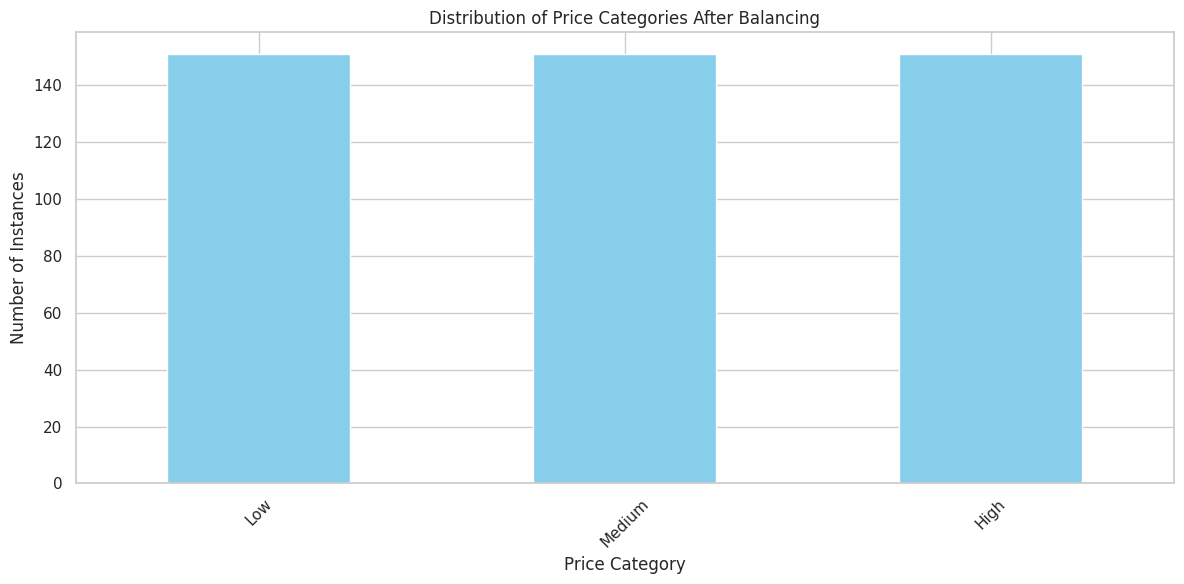

In [53]:
features = [
    'age', 'years_gaming', 'weekly_play_sessions', 'late_night_sessions_hours',
    'weekend_playtime_hours', 'consecutive_hours_max', 'multiplayer_ratio',
    'toxic_chat_reports', 'rage_quit_frequency', 'in_game_purchases',
    'lootbox_openings', 'loneliness_score', 'dopamine_dependency_index',
    'self_control_score', 'impulsiveness_score', 'anxiety_level',
    'depression_indicator', 'emotional_stability', 'sleep_hours',
    'exercise_frequency_per_week', 'caffeine_intake_cups_day',
    'social_interaction_hours', 'missed_deadlines', 'productivity_drop_percent',
    'screen_time_total_hours', 'addiction_score', 'addiction_binary',
    'burnout_probability', 'mental_health_risk_score'
]


X_train, X_test, y_train, y_test = train_test_split(
    df[features], df['gpa_group'], test_size=0.2, random_state=42, stratify=df['gpa_group']
)

train_df = pd.concat([X_train, y_train], axis=1)
max_size = train_df['gpa_group'].value_counts().max()

train_balanced = (
    train_df.groupby('gpa_group', group_keys=False, observed=True)
            .apply(lambda grp: resample(grp, replace=True, n_samples=max_size, random_state=42))
            .reset_index(drop=True)
)

X_train_bal = train_balanced[features]
y_train_bal = train_balanced['gpa_group']

print("Balanced TRAIN distribution:")
print(y_train_bal.value_counts())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

plt.figure(figsize=(12, 6))
y_train_bal.value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Price Categories After Balancing')
plt.xlabel('Price Category')
plt.ylabel('Number of Instances')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()

# PCA IMPLEMENTATION




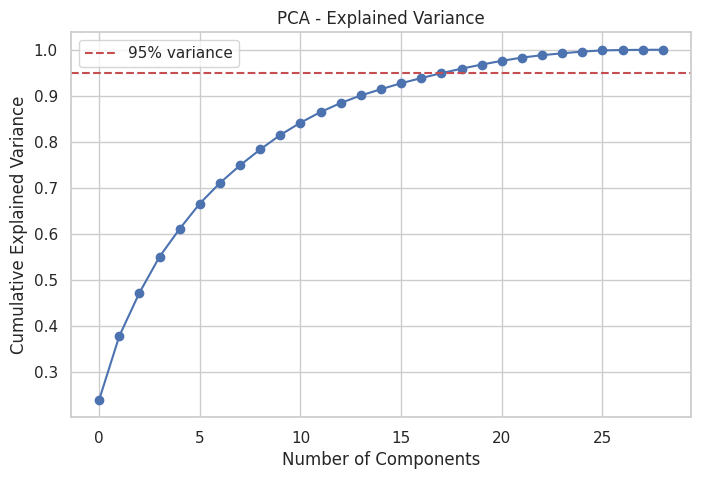

Number of components for 95% variance: 19
Shape after PCA: (453, 19)


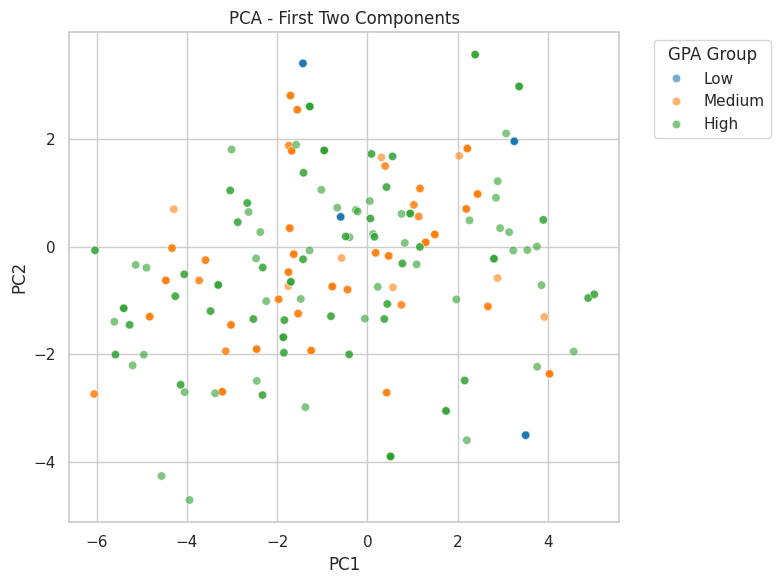

In [54]:
pca_full = PCA().fit(X_train_scaled)

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Explained Variance")
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.legend()
plt.grid(True)
plt.show()

n_components = np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.95) + 1
print(f"Number of components for 95% variance: {n_components}")

pca = PCA(n_components=n_components, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Shape after PCA:", X_train_pca.shape)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train_bal, palette='tab10', alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - First Two Components")
plt.legend(title='GPA Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**TOP 15 FEATURE HEATMAP**

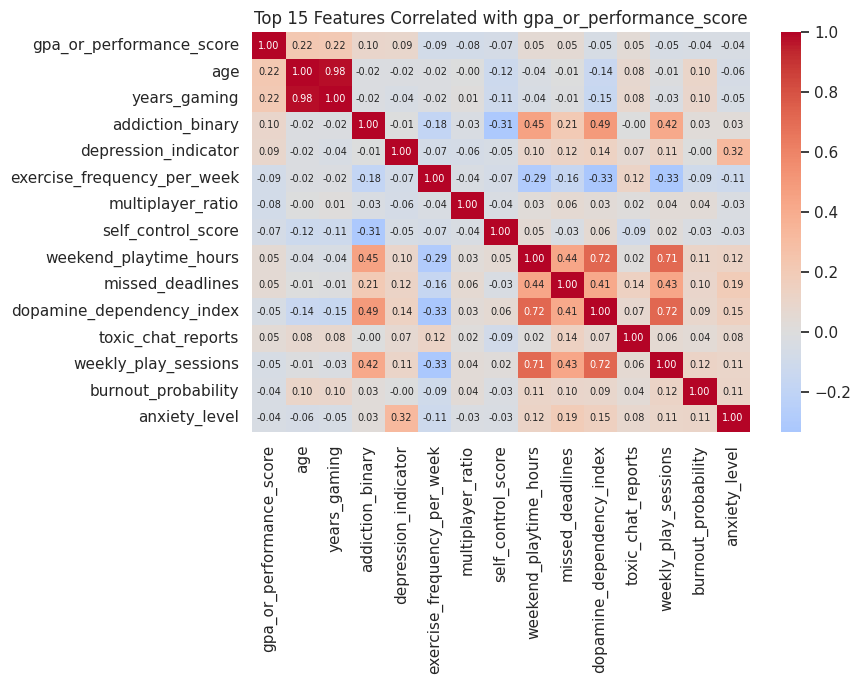

In [55]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
pca_cols = [f'PC{i+1}' for i in range(pca.n_components_)]
loadings = pd.DataFrame(
    pca.components_.T,
    index=X_train_scaled.columns,
    columns=pca_cols
)

target = 'gpa_or_performance_score'
top_features = df_numerical.corr()[target].abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(9, 7))
sns.heatmap(df_numerical[top_features].corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0, annot_kws={"size": 7})
plt.title(f"Top 15 Features Correlated with {target}")
plt.tight_layout()
plt.savefig('correlation_heatmap_top15.png', dpi=300, bbox_inches='tight')
plt.show()

# Balance based on PCA And Scaling

In [56]:
bins = [-np.inf, 2.50, 3.50, np.inf]
labels = ['Low', 'Medium', 'High']
df['gpa_group'] = pd.cut(df['gpa_or_performance_score'], bins=bins, labels=labels, right=False)


features = [
    'age', 'years_gaming', 'weekly_play_sessions', 'late_night_sessions_hours',
    'weekend_playtime_hours', 'consecutive_hours_max', 'multiplayer_ratio',
    'toxic_chat_reports', 'rage_quit_frequency', 'in_game_purchases',
    'lootbox_openings', 'loneliness_score', 'dopamine_dependency_index',
    'self_control_score', 'impulsiveness_score', 'anxiety_level',
    'depression_indicator', 'emotional_stability', 'sleep_hours',
    'exercise_frequency_per_week', 'caffeine_intake_cups_day',
    'social_interaction_hours', 'missed_deadlines', 'productivity_drop_percent',
    'screen_time_total_hours', 'addiction_score', 'addiction_binary',
    'burnout_probability', 'mental_health_risk_score'
]

X_train, X_test, y_train, y_test = train_test_split(
    df[features], df['gpa_group'], test_size=0.2, random_state=42, stratify=df['gpa_group']
)

train_df = pd.concat([X_train, y_train], axis=1)
max_size = train_df['gpa_group'].value_counts().max()

train_balanced = (
    train_df.groupby('gpa_group', group_keys=False, observed=True)
            .apply(lambda grp: resample(grp, replace=True, n_samples=max_size, random_state=42))
            .reset_index(drop=True)
)

X_train_bal = train_balanced[features]
y_train_bal = train_balanced['gpa_group']
y_train_bal = y_train_bal.astype(str)
y_test = y_test.astype(str)
y_train = y_train.astype(str)

print("Balanced TRAIN distribution:")
print(y_train_bal.value_counts())
print("\nOriginal TEST distribution (untouched):")
print(y_test.value_counts())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

Balanced TRAIN distribution:
gpa_group
Low       151
Medium    151
High      151
Name: count, dtype: int64

Original TEST distribution (untouched):
gpa_group
High      38
Medium    11
Low        1
Name: count, dtype: int64


/tmp/ipykernel_5125/2128276591.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grp: resample(grp, replace=True, n_samples=max_size, random_state=42))


ENCODING BEFORE TRAINING

In [57]:
classes = np.unique(y_train_bal)
y_test_bin = label_binarize(y_test, classes=classes)

le = LabelEncoder()
le.fit(classes)
y_train_bal_enc = le.transform(y_train_bal)

DECISION TREE

In [58]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42, max_depth=6)
dt.fit(X_train_pca, y_train_bal)
y_pred_dt = dt.predict(X_test_pca)
y_proba_dt = dt.predict_proba(X_test_pca)[:, [list(dt.classes_).index(c) for c in classes]]

print("=== Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

=== Decision Tree ===
Accuracy: 0.56
              precision    recall  f1-score   support

        High       0.77      0.63      0.70        38
         Low       0.00      0.00      0.00         1
      Medium       0.22      0.36      0.28        11

    accuracy                           0.56        50
   macro avg       0.33      0.33      0.32        50
weighted avg       0.64      0.56      0.59        50



LOGISTIC REGRESSION

In [59]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_pca, y_train_bal)
y_pred_lr = logreg.predict(X_test_pca)
y_proba_lr = logreg.predict_proba(X_test_pca)[:, [list(logreg.classes_).index(c) for c in classes]]

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression ===
Accuracy: 0.44
              precision    recall  f1-score   support

        High       0.71      0.45      0.55        38
         Low       0.00      0.00      0.00         1
      Medium       0.23      0.45      0.30        11

    accuracy                           0.44        50
   macro avg       0.31      0.30      0.28        50
weighted avg       0.59      0.44      0.48        50



RANDOM FOREST

In [60]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf.fit(X_train_pca, y_train_bal)
y_pred_rf = rf.predict(X_test_pca)
y_proba_rf = rf.predict_proba(X_test_pca)[:, [list(rf.classes_).index(c) for c in classes]]

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
Accuracy: 0.72
              precision    recall  f1-score   support

        High       0.77      0.89      0.83        38
         Low       0.00      0.00      0.00         1
      Medium       0.33      0.18      0.24        11

    accuracy                           0.72        50
   macro avg       0.37      0.36      0.35        50
weighted avg       0.66      0.72      0.68        50



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


XGBOOST

In [61]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', random_state=42
)
xgb.fit(X_train_pca, y_train_bal_enc)
y_pred_xgb_enc = xgb.predict(X_test_pca)
y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)

xgb_class_order = le.inverse_transform(xgb.classes_)
y_proba_xgb = xgb.predict_proba(X_test_pca)[:, [list(xgb_class_order).index(c) for c in classes]]

print("=== XGBoost ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

=== XGBoost ===
Accuracy: 0.76
              precision    recall  f1-score   support

        High       0.81      0.92      0.86        38
         Low       0.00      0.00      0.00         1
      Medium       0.43      0.27      0.33        11

    accuracy                           0.76        50
   macro avg       0.41      0.40      0.40        50
weighted avg       0.71      0.76      0.73        50



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


SVC

In [62]:
from sklearn.svm import SVC

svm = SVC(
    kernel='rbf', C=1.0, gamma='scale',
    probability=True, class_weight='balanced', random_state=42
)
svm.fit(X_train_pca, y_train_bal)
y_pred_svm = svm.predict(X_test_pca)
y_proba_svm = svm.predict_proba(X_test_pca)[:, [list(svm.classes_).index(c) for c in classes]]

print("=== SVM ===")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

=== SVM ===
Accuracy: 0.58
              precision    recall  f1-score   support

        High       0.76      0.68      0.72        38
         Low       0.00      0.00      0.00         1
      Medium       0.19      0.27      0.22        11

    accuracy                           0.58        50
   macro avg       0.32      0.32      0.31        50
weighted avg       0.62      0.58      0.60        50



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


NEURAL NETWORK

In [63]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    alpha=0.01,
    max_iter=1000,
    early_stopping=False,
    random_state=42
)
mlp.fit(X_train_pca, y_train_bal)
y_pred_mlp = mlp.predict(X_test_pca)
y_proba_mlp = mlp.predict_proba(X_test_pca)[:, [list(mlp.classes_).index(c) for c in classes]]

print("=== Neural Network (MLP) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))

=== Neural Network (MLP) ===
Accuracy: 0.56
              precision    recall  f1-score   support

        High       0.79      0.61      0.69        38
         Low       0.00      0.00      0.00         1
      Medium       0.24      0.45      0.31        11

    accuracy                           0.56        50
   macro avg       0.34      0.35      0.33        50
weighted avg       0.66      0.56      0.59        50



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


GRADIENT BOOSTING

In [64]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=150, max_depth=3, learning_rate=0.05,
    subsample=0.8, random_state=42
)
gb.fit(X_train_pca, y_train_bal)
y_pred_gb = gb.predict(X_test_pca)
y_proba_gb = gb.predict_proba(X_test_pca)[:, [list(gb.classes_).index(c) for c in classes]]

print("=== Gradient Boosting ===")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

=== Gradient Boosting ===
Accuracy: 0.7
              precision    recall  f1-score   support

        High       0.77      0.89      0.83        38
         Low       0.00      0.00      0.00         1
      Medium       0.17      0.09      0.12        11

    accuracy                           0.70        50
   macro avg       0.31      0.33      0.32        50
weighted avg       0.62      0.70      0.66        50



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


MODEL EVALUATION

In [65]:
def evaluate_model(name, y_true, y_pred, y_proba, y_true_bin, classes):
    acc = accuracy_score(y_true, y_pred)
    precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    precision_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    recall_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    auc_macro = roc_auc_score(y_true_bin, y_proba, average='macro', multi_class='ovr')
    auc_weighted = roc_auc_score(y_true_bin, y_proba, average='weighted', multi_class='ovr')

    print(f"=== {name} ===")
    print(f"Accuracy:            {acc:.4f}")
    print(f"Precision (macro):   {precision_macro:.4f}")
    print(f"Precision (weighted):{precision_weighted:.4f}")
    print(f"Recall (macro):      {recall_macro:.4f}")
    print(f"Recall (weighted):   {recall_weighted:.4f}")
    print(f"F1 (macro):          {f1_macro:.4f}")
    print(f"F1 (weighted):       {f1_weighted:.4f}")
    print(f"AUC-ROC (macro):     {auc_macro:.4f}")
    print(f"AUC-ROC (weighted):  {auc_weighted:.4f}")
    print()

    return {
        'Model': name, 'Accuracy': acc,
        'Precision_macro': precision_macro, 'Precision_weighted': precision_weighted,
        'Recall_macro': recall_macro, 'Recall_weighted': recall_weighted,
        'F1_macro': f1_macro, 'F1_weighted': f1_weighted,
        'AUC_macro': auc_macro, 'AUC_weighted': auc_weighted
    }

model_outputs = {
    "Decision Tree":        (y_pred_dt, y_proba_dt),
    "Logistic Regression":  (y_pred_lr, y_proba_lr),
    "Random Forest":        (y_pred_rf, y_proba_rf),
    "XGBoost":               (y_pred_xgb, y_proba_xgb),
    "SVM":                   (y_pred_svm, y_proba_svm),
    "Neural Network":        (y_pred_mlp, y_proba_mlp),
    "Gradient Boosting":     (y_pred_gb, y_proba_gb),
}

results = [evaluate_model(name, y_test, y_pred, y_proba, y_test_bin, classes)
           for name, (y_pred, y_proba) in model_outputs.items()]

results_df = pd.DataFrame(results)
display(results_df)

=== Decision Tree ===
Accuracy:            0.5600
Precision (macro):   0.3321
Precision (weighted):0.6373
Recall (macro):      0.3317
Recall (weighted):   0.5600
F1 (macro):          0.3238
F1 (weighted):       0.5894
AUC-ROC (macro):     0.5309
AUC-ROC (weighted):  0.5592

=== Logistic Regression ===
Accuracy:            0.4400
Precision (macro):   0.3119
Precision (weighted):0.5883
Recall (macro):      0.3006
Recall (weighted):   0.4400
F1 (macro):          0.2838
F1 (weighted):       0.4834
AUC-ROC (macro):     0.5969
AUC-ROC (weighted):  0.4711

=== Random Forest ===
Accuracy:            0.7200
Precision (macro):   0.3687
Precision (weighted):0.6606
Recall (macro):      0.3589
Recall (weighted):   0.7200
F1 (macro):          0.3549
F1 (weighted):       0.6820
AUC-ROC (macro):     0.6838
AUC-ROC (weighted):  0.5661

=== XGBoost ===
Accuracy:            0.7600
Precision (macro):   0.4142
Precision (weighted):0.7129
Recall (macro):      0.3979
Recall (weighted):   0.7600
F1 (macro):  

,Model,Accuracy,Precision_macro,Precision_weighted,Recall_macro,Recall_weighted,F1_macro,F1_weighted,AUC_macro,AUC_weighted
0,Decision Tree,0.56,0.332139,0.637276,0.331738,0.56,0.323838,0.589385,0.530914,0.559155
1,Logistic Regression,0.44,0.311869,0.588333,0.300638,0.44,0.283806,0.483441,0.596880,0.471070
2,Random Forest,0.72,0.368687,0.660606,0.358852,0.72,0.354854,0.682009,0.683806,0.566060
3,XGBoost,0.76,0.414175,0.712890,0.397927,0.76,0.399177,0.730123,0.678659,0.539231
4,SVM,0.58,0.317402,0.622426,0.318979,0.58,0.314815,0.597778,0.662025,0.516410
5,Neural Network,0.56,0.343733,0.655140,0.353270,0.56,0.333022,0.590541,0.636861,0.577329
6,Gradient Boosting,0.70,0.313131,0.623939,0.328549,0.70,0.315638,0.656126,0.688747,0.620115


CONFUSION MATRIX

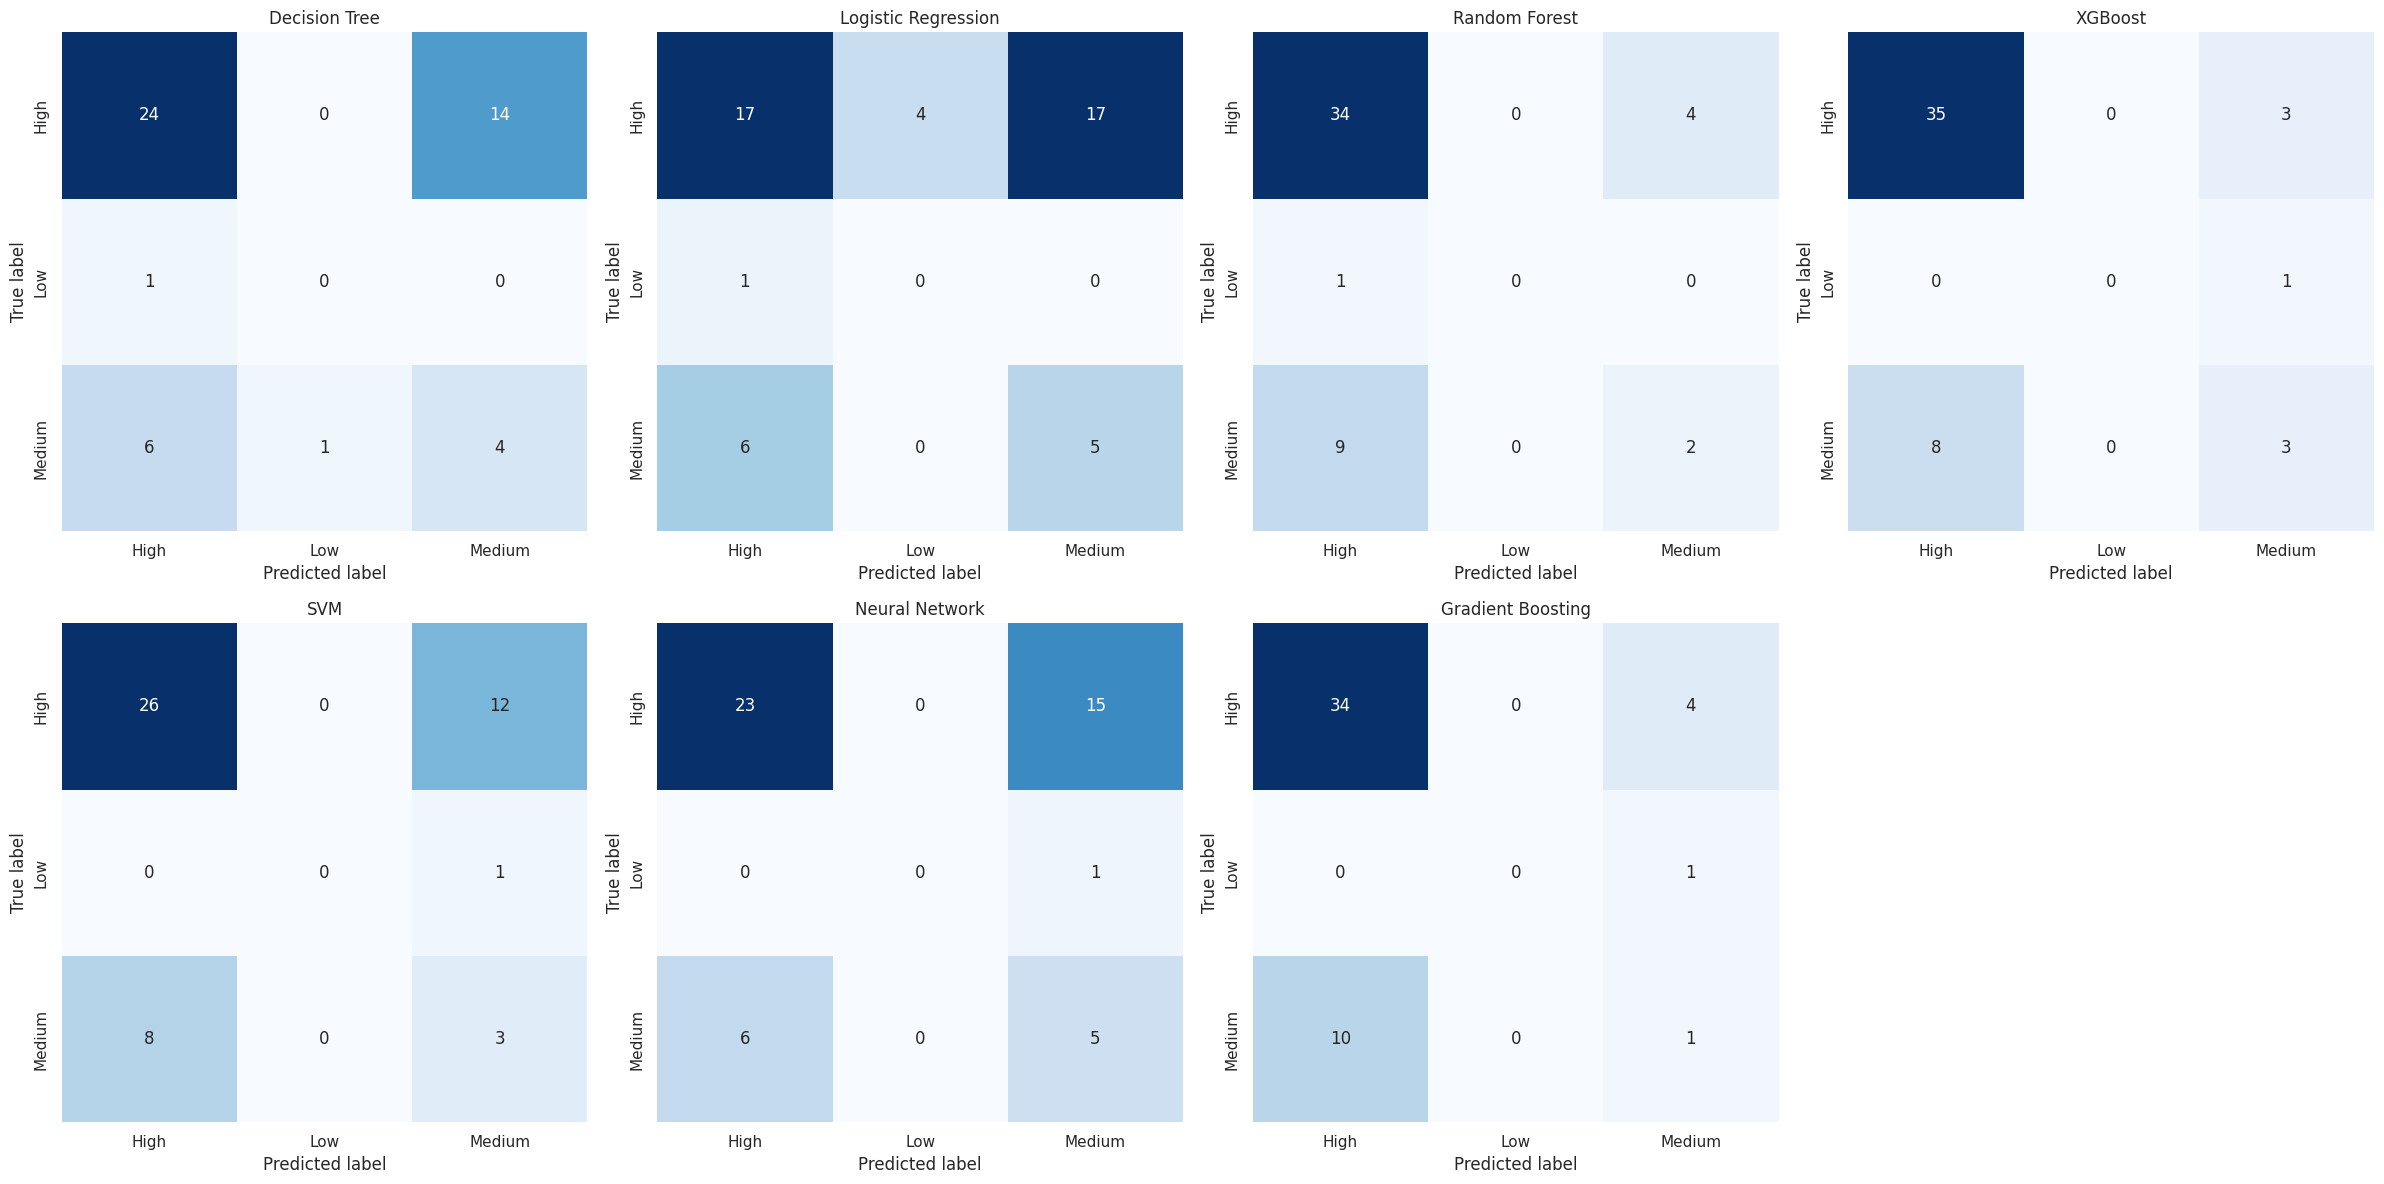

In [66]:
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

for ax, (name, (y_pred, _)) in zip(axes, model_outputs.items()):
    cm = confusion_matrix(y_test, y_pred, labels=classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

axes[-1].axis('off')

plt.tight_layout()
plt.show()

AUC ROC VISUALS

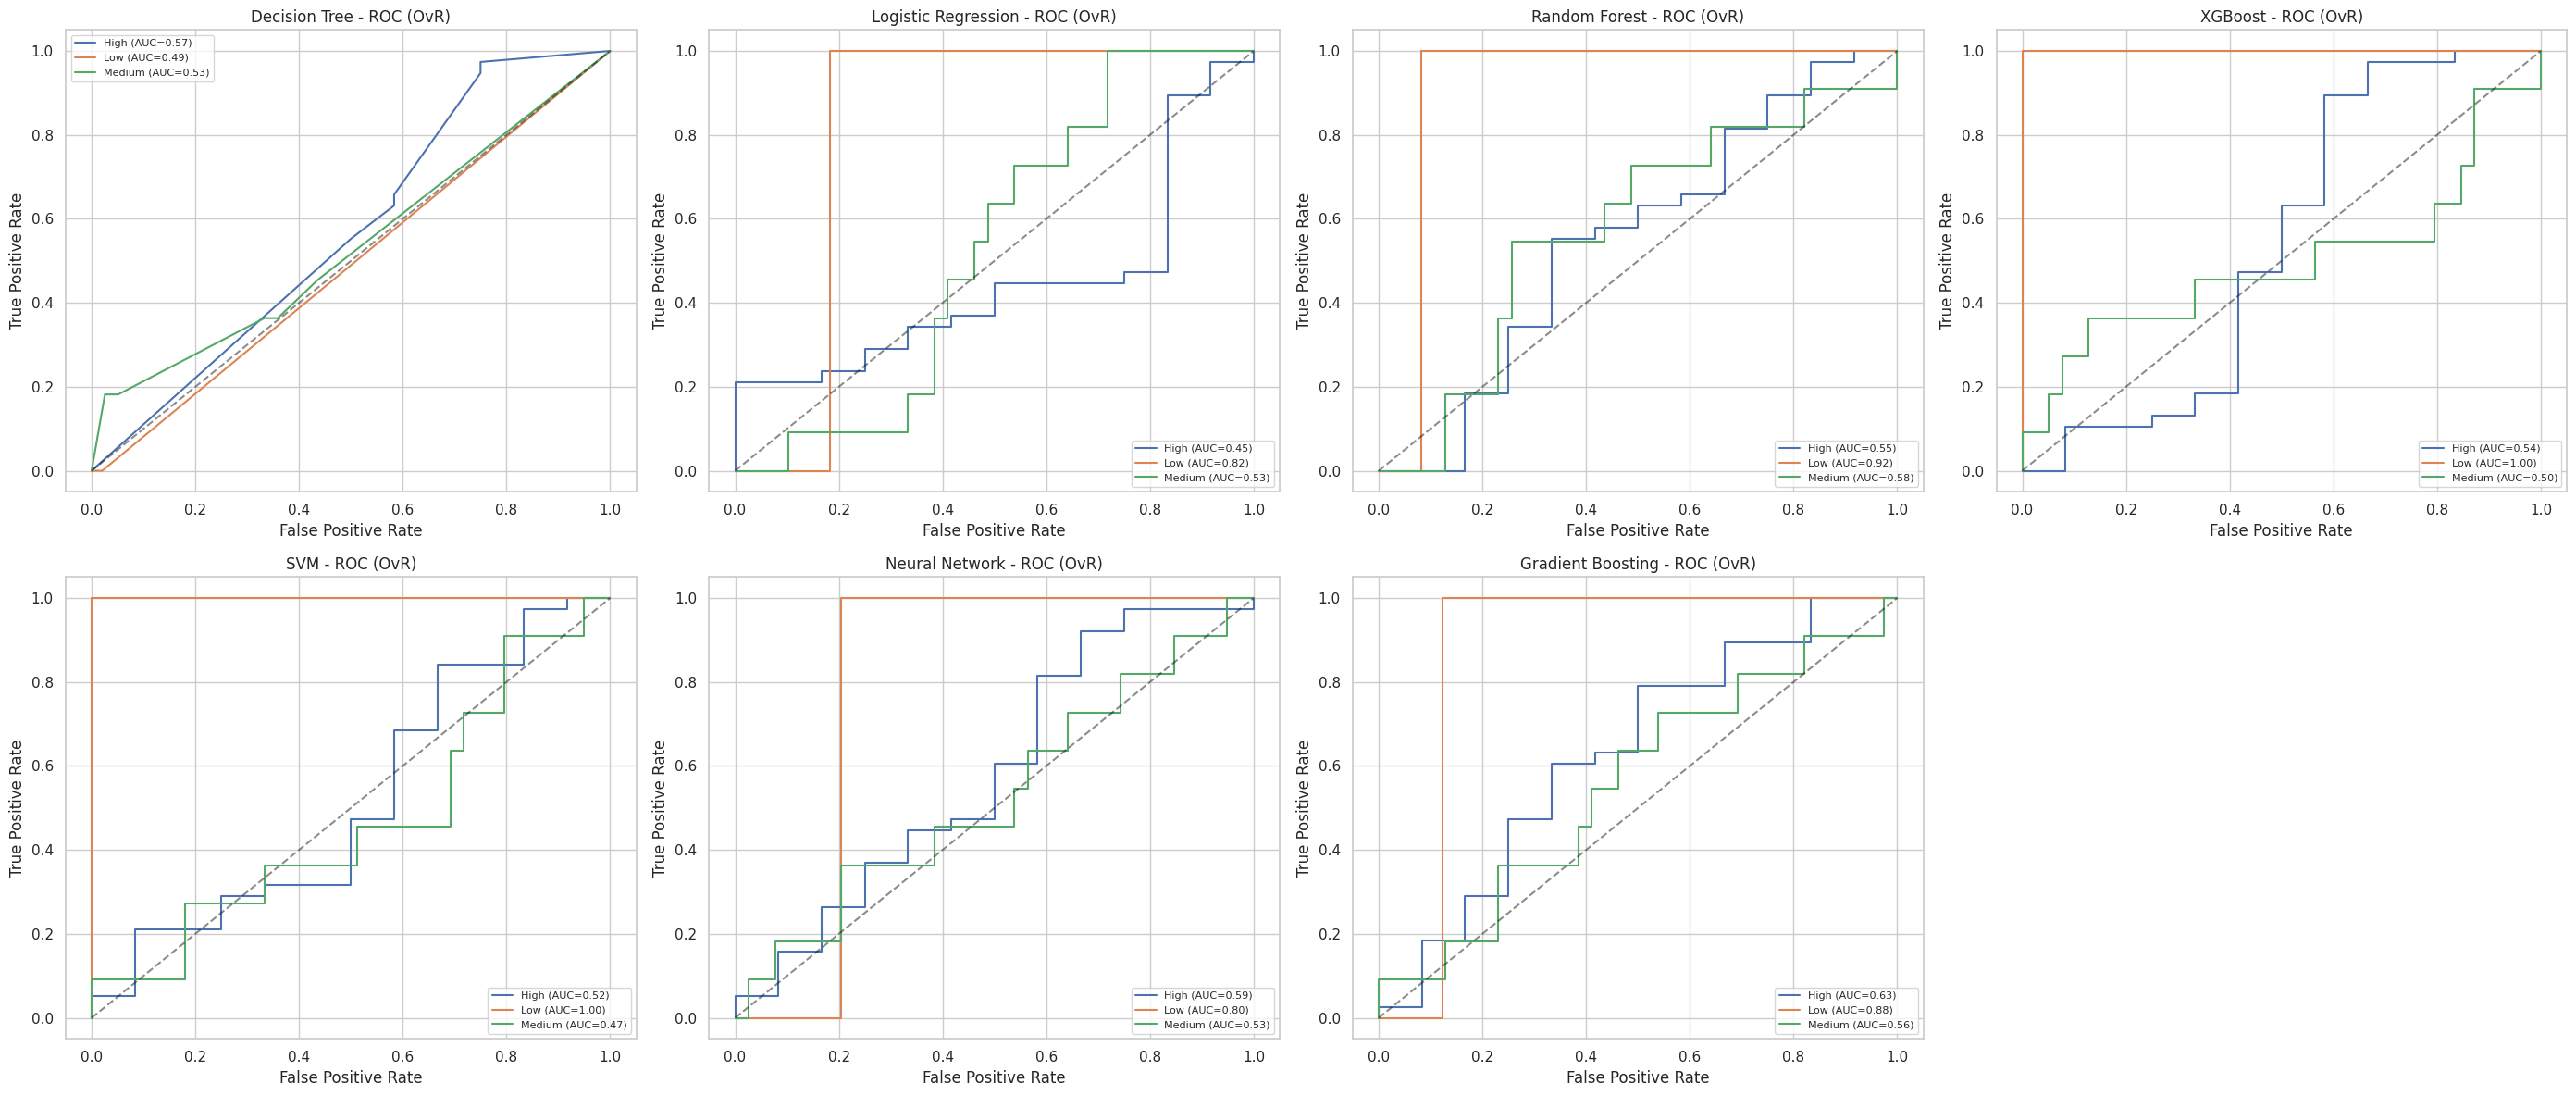

In [67]:
fig, axes = plt.subplots(2, 4, figsize=(28, 12))
axes = axes.flatten()

for ax, (name, (_, y_proba)) in zip(axes, model_outputs.items()):
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{cls} (AUC={roc_auc:.2f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{name} - ROC (OvR)")
    ax.legend(fontsize=8)

axes[-1].axis('off')

plt.tight_layout()
plt.show()

COMPARISON

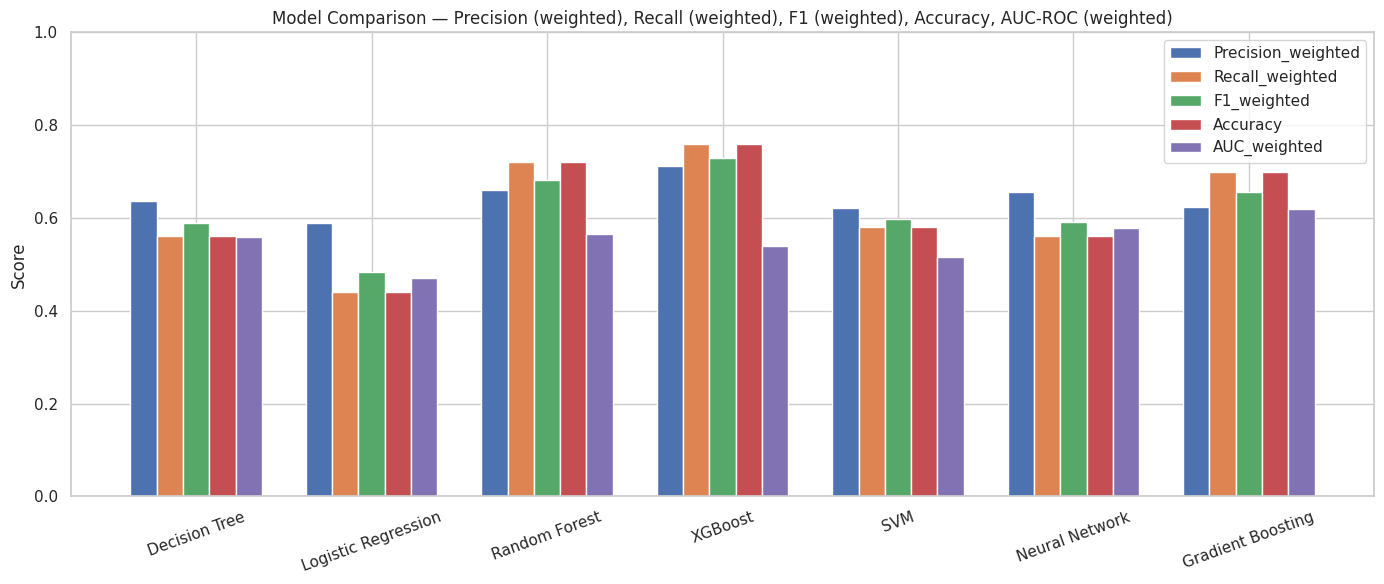

In [68]:
metrics = ['Precision_weighted', 'Recall_weighted', 'F1_weighted', 'Accuracy', 'AUC_weighted']
x = np.arange(len(results_df))
n = len(metrics)
width = 0.15

plt.figure(figsize=(14, 6))
for i, metric in enumerate(metrics):
    offset = (i - (n - 1) / 2) * width
    plt.bar(x + offset, results_df[metric], width, label=metric)

plt.xticks(x, results_df['Model'], rotation=20)
plt.ylabel("Score")
plt.title("Model Comparison — Precision (weighted), Recall (weighted), F1 (weighted), Accuracy, AUC-ROC (weighted)")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()